# Assignment 3: CNN-LSTM, ViT, and Object Tracking
## Section 1: Action Recognition using CNN-LSTM on the UCF11 Dataset
### Prasanna Paithankar (21CS30065)

6th April 2026

In [1]:
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [ ]:
class UCF11Dataset(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file)
        self.transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.5], std=[0.5]),
            ]
        )

    def __len__(self):
        return len(self.data)

    def extract_frames(self, video_path, num_frames=16):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (64, 64))
            frames.append(self.transform(resized))

        cap.release()

        while len(frames) < num_frames:
            frames.append(torch.zeros((1, 64, 64)))

        return torch.stack(frames)

    def __getitem__(self, idx):
        video_path = self.data.iloc[idx, 0]
        label = self.data.iloc[idx, 1]
        frames = self.extract_frames(video_path)
        return frames, torch.tensor(label, dtype=torch.long)

In [ ]:
import torch.nn as nn
import torchvision.models as models


class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=11):
        super(CNN_LSTM, self).__init__()
        resnet = models.resnet18(weights="DEFAULT")
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        for param in resnet.parameters():
            param.requires_grad = False

        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])

        self.lstm = nn.LSTM(
            input_size=512, hidden_size=256, num_layers=1, batch_first=True
        )
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()

        x = x.view(batch_size * seq_len, c, h, w)
        features = self.feature_extractor(x)
        features = features.view(batch_size, seq_len, -1)

        lstm_out, (h_n, c_n) = self.lstm(features)

        out = self.fc(h_n[-1])
        return out

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 2

train_dataset = UCF11Dataset("output_csv_folder/train_map.csv")
val_dataset = UCF11Dataset("output_csv_folder/val_map.csv")
test_dataset = UCF11Dataset("output_csv_folder/test_map.csv")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 72
Number of validation batches: 9


In [ ]:
import matplotlib.pyplot as plt
import torch.optim as optim

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

model = CNN_LSTM(num_classes=11).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 5

history = {"train_loss": [], "train_acc": [], "val_acc": []}

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_acc = correct_val / total_val

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

Using device: cpu
Starting Training...
Epoch [1/5] | Train Loss: 2.2330 | Train Acc: 0.2370 | Val Acc: 0.3101
Epoch [2/5] | Train Loss: 1.8258 | Train Acc: 0.3958 | Val Acc: 0.3953
Epoch [3/5] | Train Loss: 1.5938 | Train Acc: 0.4948 | Val Acc: 0.4806
Epoch [4/5] | Train Loss: 1.4286 | Train Acc: 0.5625 | Val Acc: 0.5504
Epoch [5/5] | Train Loss: 1.3422 | Train Acc: 0.5729 | Val Acc: 0.5659


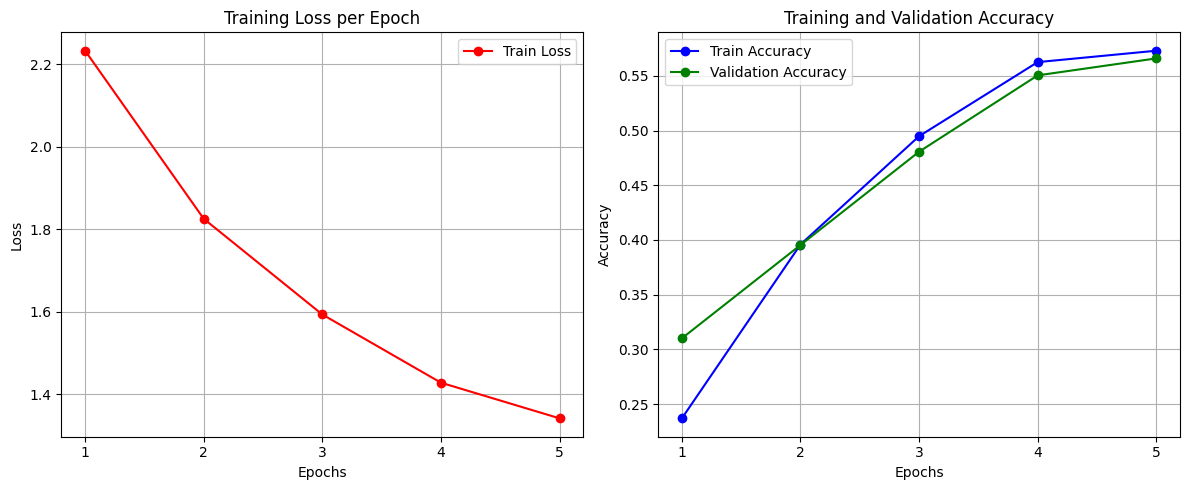

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    range(1, epochs + 1),
    history["train_loss"],
    label="Train Loss",
    color="red",
    marker="o",
)
plt.title("Training Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(range(1, epochs + 1))
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    range(1, epochs + 1),
    history["train_acc"],
    label="Train Accuracy",
    color="blue",
    marker="o",
)
plt.plot(
    range(1, epochs + 1),
    history["val_acc"],
    label="Validation Accuracy",
    color="green",
    marker="o",
)
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1, epochs + 1))
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("Starting Testing...")
model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

final_test_acc = correct_test / total_test
print(f"=====================================")
print(f"Final Test Accuracy: {final_test_acc * 100:.2f}%")
print(f"=====================================")

Starting Testing...
Final Test Accuracy: 17.03%


In [ ]:
torch.save(
    {"model_state_dict": model.state_dict(), "history": history}, "cnn_lstm_ucf11.pth"
)

***